In [201]:
from diffusion_models.models import diffusion as dd
import diffusion_models.utils.common_logging as cl
import numpy as np
from diffusion_models.utils import common_utils as ut
import pandas as pd
import os
import pymc as pm
from pytensor import tensor as at

In [202]:
(0.2515518 + 2*0.0008319) * np.exp( ((0.2515518 + 2*0.0008319)**2) / (2*0.0008319) )

1.3802884675754678e+16

In [203]:
v, a, z, t_er, lp_v, X, RT = dd._test_likelihood_using_prior(100, 20)
v = 1.5
a = 2
z = 0.5
t_er = 0.55

2023-02-28 17:50:40,880 - diffusion - DEBUG - Starting Diffusion test


DEBUG:diffusion:Starting Diffusion test


2023-02-28 17:50:50,449 - diffusion - DEBUG - lp: [[ -5817.37445936      0.          -3055.49835896 ...  -7731.00081444
       0.         -17373.93668794]
 [ -6918.88381267      0.              0.         ...   -210.84285056
       0.              0.        ]
 [-12629.28240625 -14790.1143948  -15727.3454787  ...  -5608.26683249
       0.         -19820.81521621]
 ...
 [-13376.12604629 -13205.12625547 -24183.37476639 ... -23109.01198998
  -13257.74639837 -12910.82793373]
 [ -4998.86027866  -8290.2102162   -9139.12784799 ... -10634.42614631
  -21367.68215911 -11072.9948766 ]
 [-20042.2786444  -10374.07073954  -9054.16044648 ...  -7334.55163302
   -2779.64565044 -10906.32316824]]


DEBUG:diffusion:lp: [[ -5817.37445936      0.          -3055.49835896 ...  -7731.00081444
       0.         -17373.93668794]
 [ -6918.88381267      0.              0.         ...   -210.84285056
       0.              0.        ]
 [-12629.28240625 -14790.1143948  -15727.3454787  ...  -5608.26683249
       0.         -19820.81521621]
 ...
 [-13376.12604629 -13205.12625547 -24183.37476639 ... -23109.01198998
  -13257.74639837 -12910.82793373]
 [ -4998.86027866  -8290.2102162   -9139.12784799 ... -10634.42614631
  -21367.68215911 -11072.9948766 ]
 [-20042.2786444  -10374.07073954  -9054.16044648 ...  -7334.55163302
   -2779.64565044 -10906.32316824]]


2023-02-28 17:50:58,299 - diffusion - DEBUG - X:[[1 1 1 ... 1 1 1]
 [1 0 1 ... 1 0 0]
 [0 0 0 ... 1 1 0]
 ...
 [1 1 0 ... 0 1 0]
 [0 0 0 ... 1 0 0]
 [1 0 0 ... 0 0 0]]


DEBUG:diffusion:X:[[1 1 1 ... 1 1 1]
 [1 0 1 ... 1 0 0]
 [0 0 0 ... 1 1 0]
 ...
 [1 1 0 ... 0 1 0]
 [0 0 0 ... 1 0 0]
 [1 0 0 ... 0 0 0]]


2023-02-28 17:50:58,316 - diffusion - DEBUG - RT:[[1.47536348 0.02718864 0.95041337 ... 1.83640617 0.21669128 3.74563614]
 [2.88317605 0.56218027 0.99246077 ... 1.5975463  0.80239455 0.84189611]
 [2.46014249 2.90484236 3.07811921 ... 1.36049294 0.0096731  3.90047208]
 ...
 [0.32334577 0.31777342 2.18156723 ... 1.92087535 0.33503179 0.02379951]
 [0.0663949  0.71431441 0.87393875 ... 1.38893628 3.25914748 1.26508254]
 [3.95042533 1.86832188 1.60784953 ... 1.25880117 0.39866122 1.98291901]]


DEBUG:diffusion:RT:[[1.47536348 0.02718864 0.95041337 ... 1.83640617 0.21669128 3.74563614]
 [2.88317605 0.56218027 0.99246077 ... 1.5975463  0.80239455 0.84189611]
 [2.46014249 2.90484236 3.07811921 ... 1.36049294 0.0096731  3.90047208]
 ...
 [0.32334577 0.31777342 2.18156723 ... 1.92087535 0.33503179 0.02379951]
 [0.0663949  0.71431441 0.87393875 ... 1.38893628 3.25914748 1.26508254]
 [3.95042533 1.86832188 1.60784953 ... 1.25880117 0.39866122 1.98291901]]


2023-02-28 17:50:58,319 - diffusion - INFO - Test Successful!


INFO:diffusion:Test Successful!


In [204]:
lp_v.shape

(100, 20)

In [205]:
df = pd.DataFrame({"p":lp_v.flatten(), "lp":lp_v.flatten(), "RT":RT.flatten()})
df

,p,lp,RT
0,-5817.374459,-5817.374459,1.475363
1,0.000000,0.000000,0.027189
2,-3055.498359,-3055.498359,0.950413
3,-15625.957237,-15625.957237,3.384305
4,-6333.309471,-6333.309471,1.574283
...,...,...,...
1995,-10469.743684,-10469.743684,2.145741
1996,-19127.910442,-19127.910442,3.553968
1997,-7334.551633,-7334.551633,1.258801
1998,-2779.645650,-2779.645650,0.398661


<AxesSubplot: xlabel='RT', ylabel='lp'>

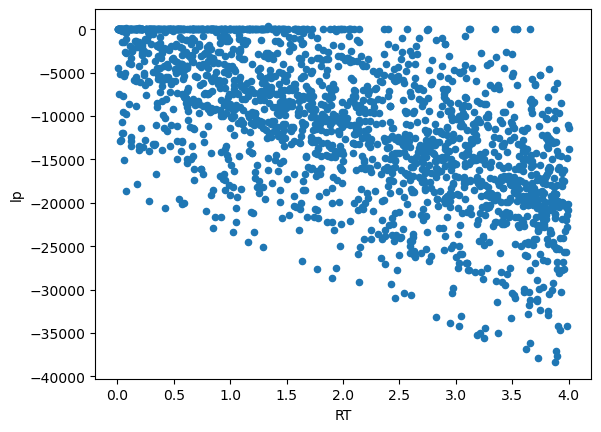

In [206]:
df.plot(x="RT", y="lp", kind="scatter")

<AxesSubplot: >

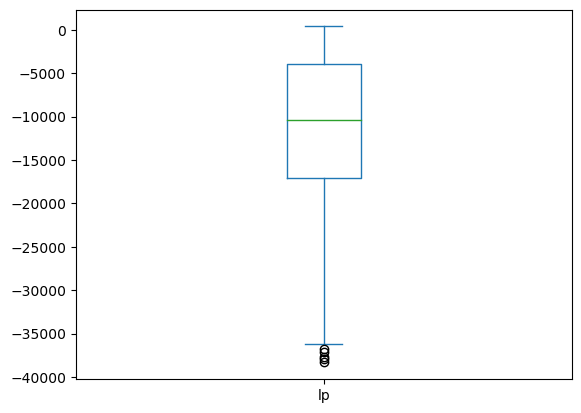

In [207]:
df.loc[:,"lp"].plot(kind="box")

In [208]:
np.save("v.npy",v)
np.save("a.npy",a)
np.save("z.npy",z)
np.save("t_er.npy",t_er)
np.save("X.npy",X)
np.save("RT.npy",RT)

In [209]:
#prior_chain = dd.sample_prior_data(10,2,9)

In [210]:
#post_chain = dd.sample_posterior_params(RT, X, 10,2,10)
